<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_02_pandas_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re


# Lab 2: Estadística Descriptiva Básica 2

## Series de tiempo

El siguiente [dataset](https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv) contiene información del precio del eur/usd  desde el 05/07/2022/ hasta el 12/05/2023 con periodicidad de una hora. El data frame contiene el precio de apertura, cierrre, valor más bajo cotizado, valor más alto cotizado, volumen, spread etc. Para este dataset, realizar lo siguiente:


1. Leer el dataset desde el github.
2. Definir como indice la columna time.
3. Obtenga información del data frame.


In [2]:
# 1. Leer el dataset desde GitHub
urlEurUsd = 'https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv'
dfEurUsd = pd.read_csv(urlEurUsd)

# 2. Definir como índice la columna time
dfEurUsd['time'] = pd.to_datetime(dfEurUsd['time'])
dfEurUsd.set_index('time', inplace=True)

# 3. Obtener información del dataframe
print("Información del DataFrame EUR/USD:\n")
print(dfEurUsd.info())
print("\n" + "="*50 + "\n")
print("Primeras filas:")
print(dfEurUsd.head())
print("\n" + "="*50 + "\n")
print("Descripción estadística:")
print(dfEurUsd.describe())

Información del DataFrame EUR/USD:

<class 'pandas.DataFrame'>
DatetimeIndex: 5000 entries, 2022-07-25 13:00:00 to 2023-05-12 23:00:00
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          5000 non-null   int64  
 1   open                5000 non-null   float64
 2   high                5000 non-null   float64
 3   low                 5000 non-null   float64
 4   close               5000 non-null   float64
 5   tick_volume         5000 non-null   int64  
 6   spread              5000 non-null   int64  
 7   real_volume         5000 non-null   int64  
 8   MeanCloseOpen       5000 non-null   float64
 9   Diff_Close          5000 non-null   float64
 10  Diff_Open           5000 non-null   float64
 11  Diff_MeanCloseOpen  5000 non-null   float64
dtypes: float64(8), int64(4)
memory usage: 507.8 KB
None


Primeras filas:
                     Unnamed: 0     open     high      low    close  \


4. Determine si hay null, nan en el data frame.

In [3]:
print("Valores nulos por columna:")
print(dfEurUsd.isnull().sum())

totalNulos = dfEurUsd.isnull().sum().sum()
print(f"\nTotal de valores nulos en el DataFrame: {totalNulos}")

Valores nulos por columna:
Unnamed: 0            0
open                  0
high                  0
low                   0
close                 0
tick_volume           0
spread                0
real_volume           0
MeanCloseOpen         0
Diff_Close            0
Diff_Open             0
Diff_MeanCloseOpen    0
dtype: int64

Total de valores nulos en el DataFrame: 0


5. Emplea la notacion Pascal Case y trabaja solo con la columa del precio de cierre del eur/usd.  

6. Ahora vamos a determinar cual es la mejor distribución estadística que se ajusta a la diferencia del precio de cierre cada hora, para ello realizamos lo siguiente:
- Determine la diferencia de precio entre horas, agregue una nueva columna llamada DiffPrice, en este punto tu dataframe debe tener solo dos columnas Close, DiffPrice y el indice debe ser el tiempo.
- Para la nueva columna construya un histograma de los datos.
- Determine la mejor distribucion estadística que se ajusta al histograma anterior, para ello puede emplear lo siguente:


https://pypi.org/project/fitter/

```python


from fitter import Fitter, get_common_distributions, get_distributions

f = Fitter(data,
           distributions=['gamma',
                          'lognorm',
                          "beta",
                          "burr",
                          "norm"])
f.fit()
f.summary()
#Indentificamos la mejor distribucion con el error cuadratico medio
f.get_best(method = 'sumsquare_error')
#Indentificamos parametros de la distrubicion beta
f.fitted_param["beta"]

```

Con el metodo get_distributions(), podemos ver todas las distribuciones estadisticas de la libreria. Ajusta a la mejor.  Puede consultar [esta](https://medium.com/the-researchers-guide/finding-the-best-distribution-that-fits-your-data-using-pythons-fitter-library-319a5a0972e9)  página si desea ver un ejemplo.

                       Close
time                        
2022-07-25 13:00:00  1.02345
2022-07-25 14:00:00  1.02299
2022-07-25 15:00:00  1.02457
2022-07-25 16:00:00  1.02485
2022-07-25 17:00:00  1.02181
                       Close  DiffPrice
time                                   
2022-07-25 14:00:00  1.02299   -0.00046
2022-07-25 15:00:00  1.02457    0.00158
2022-07-25 16:00:00  1.02485    0.00028
2022-07-25 17:00:00  1.02181   -0.00304
2022-07-25 18:00:00  1.02099   -0.00082


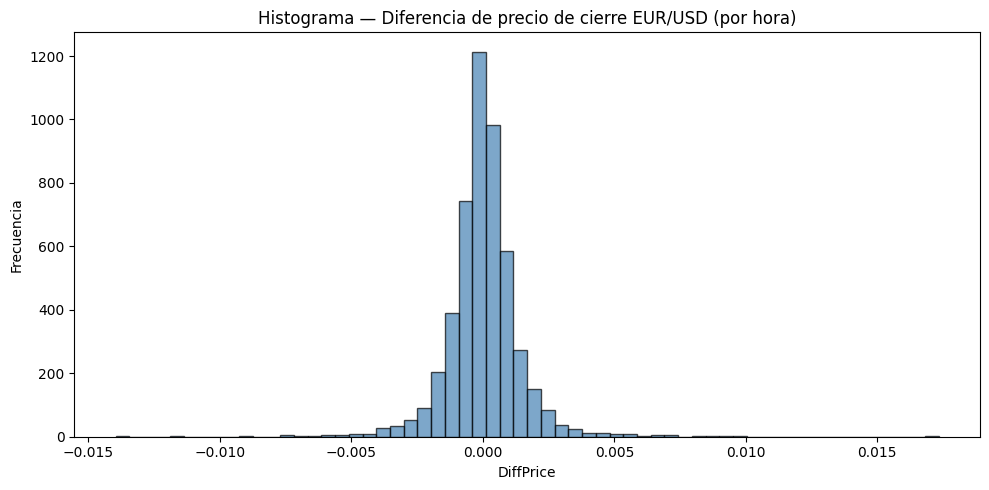

2026-03-27 00:47:25.547 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted arcsine: error=905370.026305, AIC=-30254.26, KS=0.4547
2026-03-27 00:47:25.836 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted alpha: error=118570.652431, AIC=-51388.95, KS=0.1122
2026-03-27 00:47:25.969 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted cauchy: error=23122.545603, AIC=-52492.69, KS=0.0425
2026-03-27 00:47:26.015 | WARNING  | fitter.fitter:_fit_single_distribution:422 - SKIPPED _fit: TypeError (timeout=30s or fitting failed)
2026-03-27 00:47:26.026 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted chi: error=202906.035996, AIC=-50964.41, KS=0.1422
2026-03-27 00:47:26.057 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted chi2: error=465484.062385, AIC=-46905.81, KS=0.3035
2026-03-27 00:47:26.062 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted bradford: error=802494.479432, AIC=-34634.40, KS=0.4146
2026-03-


Mejor distribución:
{'johnsonsu': {'a': np.float64(-0.020654532350683215), 'b': np.float64(1.049797421216857), 'loc': np.float64(-1.5194909287993722e-05), 'scale': np.float64(0.0008808828671326262)}}

Parámetros de johnsonsu:
(np.float64(-0.020654532350683215), np.float64(1.049797421216857), np.float64(-1.5194909287993722e-05), np.float64(0.0008808828671326262))


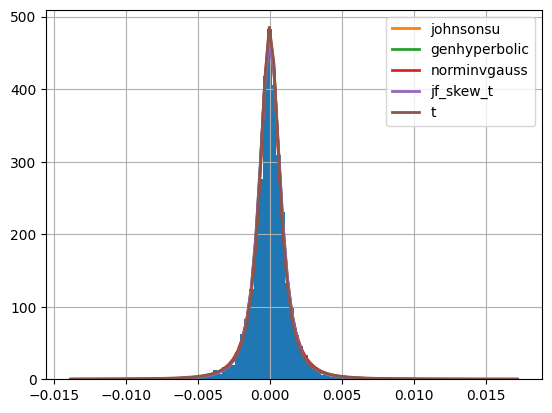

In [4]:
# 5. Notación Pascal Case — trabajar solo con precio de cierre
DfEurUsd = dfEurUsd[["close"]].copy()
DfEurUsd.columns = ["Close"]

print(DfEurUsd.head())

# 6. Diferencia de precio entre horas
DfEurUsd["DiffPrice"] = DfEurUsd["Close"].diff()
DfEurUsd.dropna(inplace=True)

print(DfEurUsd.head())

# Histograma de DiffPrice
plt.figure(figsize=(10, 5))
plt.hist(DfEurUsd["DiffPrice"], bins=60, edgecolor="black", alpha=0.7, color="steelblue")
plt.title("Histograma — Diferencia de precio de cierre EUR/USD (por hora)")
plt.xlabel("DiffPrice")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Mejor distribución estadística usando todas las distribuciones disponibles
from fitter import Fitter, get_distributions

FitterModel = Fitter(DfEurUsd["DiffPrice"], distributions=get_distributions())
FitterModel.fit()
FitterModel.summary()

BestDist = FitterModel.get_best(method="sumsquare_error")
print("\nMejor distribución:")
print(BestDist)

BestName = list(BestDist.keys())[0]
print(f"\nParámetros de {BestName}:")
print(FitterModel.fitted_param[BestName])


7. Para el data frame, seleccionemos solo los datos del 2023.

8. El comando groupby permite agrupar los datos con la periodicidad deseada: 1 dias, 2 dias, 1 mes etc. Determina el promedio con una periodicidad de 15 dias, con periodidicidad de 1 semana, y una periodicidad de 1 mes

```python
  df.groupby(pd.Grouper(key='time', freq='15D')).mean()
```

In [5]:
# 7. Seleccionar solo los datos del 2023
DfEurUsd2023 = DfEurUsd[DfEurUsd.index.year == 2023]

print(f"Registros en 2023: {len(DfEurUsd2023)}")
print(DfEurUsd2023.head())

# 8. Promedio agrupado por distintas periodicidades
Df15Dias = DfEurUsd2023.groupby(pd.Grouper(freq="15D")).mean()
DfSemanal = DfEurUsd2023.groupby(pd.Grouper(freq="W")).mean()
DfMensual = DfEurUsd2023.groupby(pd.Grouper(freq="ME")).mean()

print("Promedio cada 15 días:")
print(Df15Dias)

print("\nPromedio semanal:")
print(DfSemanal)

print("\nPromedio mensual:")
print(DfMensual)


Registros en 2023: 2278
                       Close  DiffPrice
time                                   
2023-01-02 00:00:00  1.06796   -0.00200
2023-01-02 01:00:00  1.06965    0.00169
2023-01-02 02:00:00  1.07058    0.00093
2023-01-02 03:00:00  1.06896   -0.00162
2023-01-02 04:00:00  1.06880   -0.00016
Promedio cada 15 días:
               Close  DiffPrice
time                           
2023-01-02  1.069361   0.000047
2023-01-17  1.085565   0.000015
2023-02-01  1.077679  -0.000066
2023-02-16  1.063150  -0.000034
2023-03-03  1.063186   0.000026
2023-03-18  1.080936   0.000074
2023-04-02  1.093090   0.000063
2023-04-17  1.099084  -0.000006
2023-05-02  1.098889  -0.000059

Promedio semanal:
               Close  DiffPrice
time                           
2023-01-08  1.059972  -0.000047
2023-01-15  1.076002   0.000156
2023-01-22  1.082041   0.000020
2023-01-29  1.088414   0.000010
2023-02-05  1.089281  -0.000062
2023-02-12  1.073363  -0.000097
2023-02-19  1.069648   0.000014
2023-02-26  1.

9. Para los datos asociados a los meses de 2023, construya un histograma para cada mes.  Para ello puedo emplear el metodo groupby. Notetese que si no  realiza una operación después de aplicar el metodo grouby, podrias iterar sobre dicho objeto, por ejemplo:

```python
q=df.groupby(pd.Grouper(key='time', freq='15D'))

for name, group in q:
  print(name, group)
```

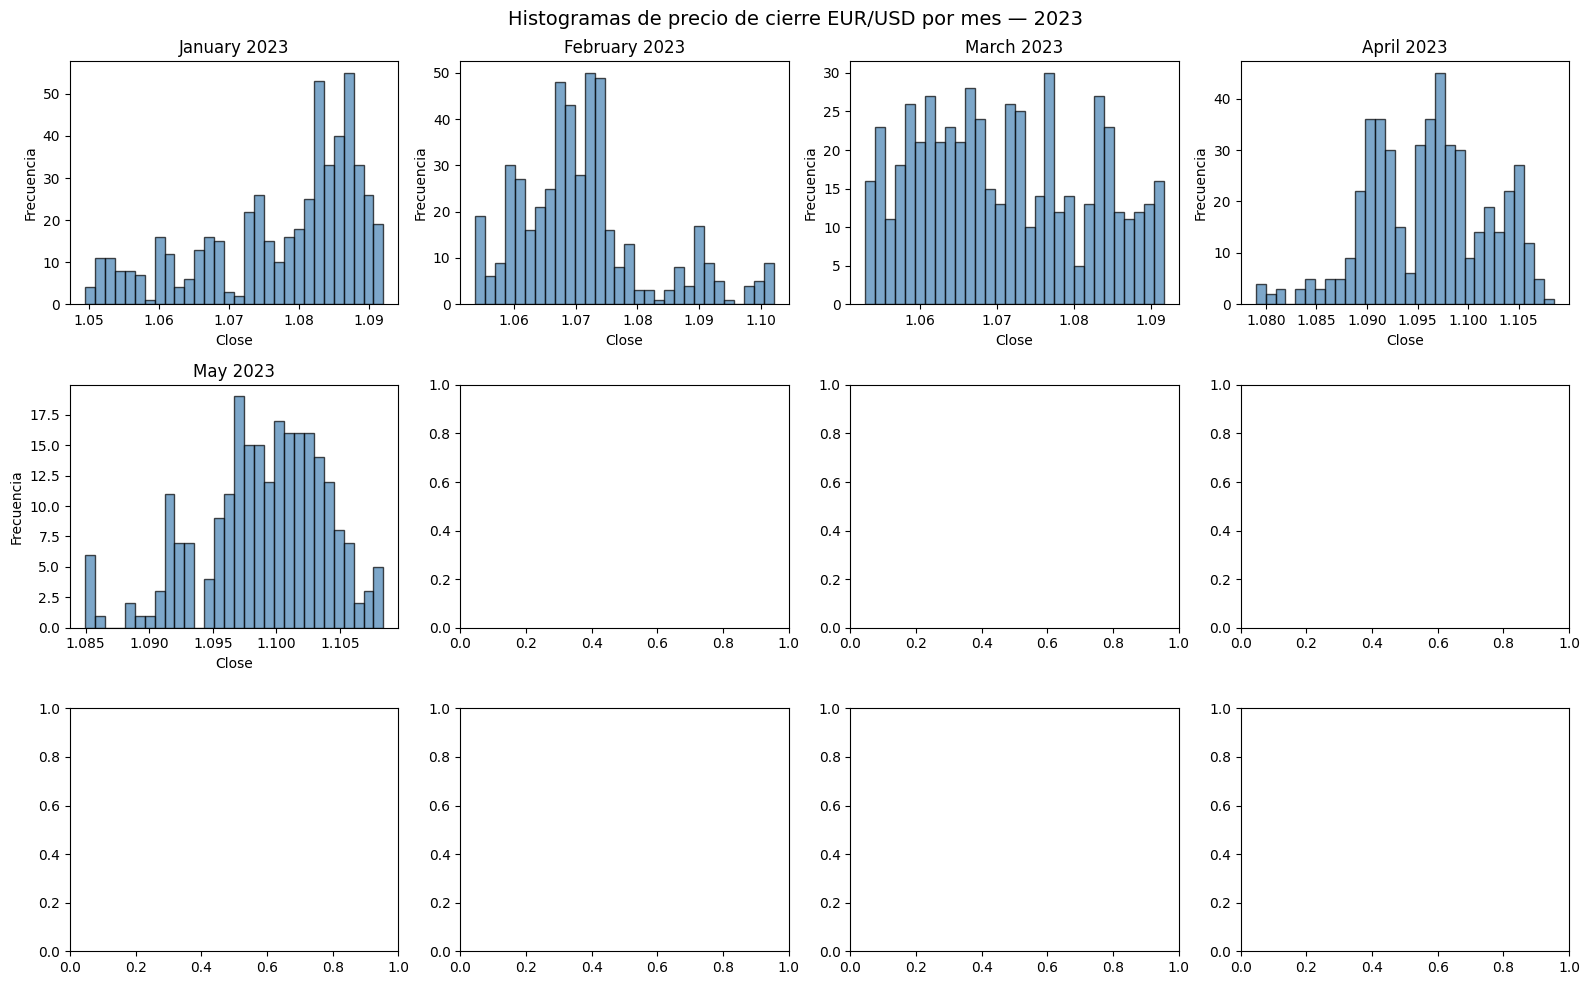

In [6]:
# 9. Histograma de Close por cada mes de 2023
GrupoPorMes = DfEurUsd2023.groupby(pd.Grouper(freq="ME"))

Fig, Axes = plt.subplots(3, 4, figsize=(16, 10))
Axes = Axes.flatten()

for Idx, (Nombre, Grupo) in enumerate(GrupoPorMes):
    if Grupo.empty:
        continue
    Axes[Idx].hist(Grupo["Close"], bins=30, color="steelblue", edgecolor="black", alpha=0.7)
    Axes[Idx].set_title(Nombre.strftime("%B %Y"))
    Axes[Idx].set_xlabel("Close")
    Axes[Idx].set_ylabel("Frecuencia")

plt.suptitle("Histogramas de precio de cierre EUR/USD por mes — 2023", fontsize=14)
plt.tight_layout()
plt.show()
# Solo hay datos hasta Mayo 2023 en el dataset.

## Análisis de datos con pandas. 

Para el siguiente [dataset](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29) realizar lo siguiente:


1. Leer los datos desde una página web.

2. Renombrar las columnas en formato PascalCase.


In [7]:
df_tumor = pd.read_csv('../datasets/wdbcdata.csv')

df_tumor.columns = [
'Id', 'Diagnosis', 'Radius1', 'Texture1', 'Perimeter1', 'Area1', 'Smoothness1', 'Compactness1', 'Concavity1', 'ConcavePoints1', 'Symmetry1', 'FractalDimension1', 'Radius2', 'Texture2', 'Perimeter2', 'Area2', 'Smoothness2', 'Compactness2', 'Concavity2', 'ConcavePoints2', 'Symmetry2', 'FractalDimension2', 'Radius3', 'Texture3', 'Perimeter3', 'Area3', 'Smoothness3', 'Compactness3', 'Concavity3', 'ConcavePoints3', 'Symmetry3', 'FractalDimension3'
]

df_tumor.head(1)

,Id,Diagnosis,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,...,Radius3,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3
0,842302,M,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189


3. Utilizar los métodos `head()`, `tail()`, `describe()` e `info()` para obtener información sobre el `DataFrame`.

In [8]:
# Información básica del DataFrame df_tumor

print("Primeras filas (head):")

print(df_tumor.head())



print("\nÚltimas filas (tail):")

print(df_tumor.tail())



print("\nResumen estadístico (describe):")

print(df_tumor.describe())



print("\nInformación general del DataFrame (info):")

df_tumor.info()

Primeras filas (head):
         Id Diagnosis  Radius1  Texture1  Perimeter1   Area1  Smoothness1  \
0    842302         M    17.99     10.38      122.80  1001.0      0.11840   
1    842517         M    20.57     17.77      132.90  1326.0      0.08474   
2  84300903         M    19.69     21.25      130.00  1203.0      0.10960   
3  84348301         M    11.42     20.38       77.58   386.1      0.14250   
4  84358402         M    20.29     14.34      135.10  1297.0      0.10030   

   Compactness1  Concavity1  ConcavePoints1  ...  Radius3  Texture3  \
0       0.27760      0.3001         0.14710  ...    25.38     17.33   
1       0.07864      0.0869         0.07017  ...    24.99     23.41   
2       0.15990      0.1974         0.12790  ...    23.57     25.53   
3       0.28390      0.2414         0.10520  ...    14.91     26.50   
4       0.13280      0.1980         0.10430  ...    22.54     16.67   

   Perimeter3   Area3  Smoothness3  Compactness3  Concavity3  ConcavePoints3  \
0      

4. Contabilizar la cantidad de valores nulos (`null` o `NaN`) en el `DataFrame`.
   
Si se encuentran valores nulos, ¿qué estrategia propondrías para reemplazarlos?

R/ Existen diversas estrategias dependiendo del contexto de la data y el patrón con que se distribuyan esos valores nulos. En este caso, el dataset ya está limpio y curado. Pero en general:

- Si una misma fila (mismo paciente) tiene muchos valores nulos respecto a los demás (e.g más de 4 o 5 valores nulos), se puede considerar: imputar esos valores con alguna medida de tendencia central de los otros pacientes, o eliminar el registro.

- Si es una de las columnas (una feature de todos los pacientes) la que tiene muchos valores nulos, se podria hacer un descarte de esa columna en los análisis o entrenamiento de los modelos, dependiendo de qué tan relevante sea para nuestro target.

In [9]:
# Conteo de valores nulos (NaN) en el DataFrame df_tumor

print("Valores nulos por columna:")

print(df_tumor.isnull().sum())



total_nulos = df_tumor.isnull().sum().sum()

print(f"\nTotal de valores nulos en todo el DataFrame: {total_nulos}")

Valores nulos por columna:
Id                   0
Diagnosis            0
Radius1              0
Texture1             0
Perimeter1           0
Area1                0
Smoothness1          0
Compactness1         0
Concavity1           0
ConcavePoints1       0
Symmetry1            0
FractalDimension1    0
Radius2              0
Texture2             0
Perimeter2           0
Area2                0
Smoothness2          0
Compactness2         0
Concavity2           0
ConcavePoints2       0
Symmetry2            0
FractalDimension2    0
Radius3              0
Texture3             0
Perimeter3           0
Area3                0
Smoothness3          0
Compactness3         0
Concavity3           0
ConcavePoints3       0
Symmetry3            0
FractalDimension3    0
dtype: int64

Total de valores nulos en todo el DataFrame: 0


5. Identificar los valores únicos en la columna `target` que representan las etiquetas B y M (Benigno y Maligno, respectivamente).
   Utiliza el método `unique()` para mostrar estos valores.

In [10]:
# Valores únicos en la columna target (Diagnosis)

print("Valores únicos en la columna Diagnosis (target):")

print(df_tumor["Diagnosis"].unique())

Valores únicos en la columna Diagnosis (target):
<StringArray>
['M', 'B']
Length: 2, dtype: str


6. Realizar un conteo de los casos etiquetados como B y M utilizando la librería `seaborn` y el método `countplot()`:

```python
import seaborn as sns
sns.countplot?
```

R/ Este plot ya lo hizo el runner.py:

![alt text](/home/ginkgo/Workspace/UdeA/FCII/semestre2026-1/Estudiantes/Moscoso_80/Laboratorios/Lab_02_pandas/artifacts/breast_cancer/plots/count_diagnosis__DESCRIBE__20260314_105600.png)


7. Agregar una nueva columna llamada `DiagnosisNumeric` donde se asigna el valor 0 a la etiqueta B (Benigno) y el valor 1 a la etiqueta M (Maligno).


8. Normalizar cada columna respecto a su media y desviación estándar utilizando la fórmula:  
   `(x - mean(x)) / std(x)`


In [11]:
# 7. Crear columna DiagnosisNumeric (0 = B, 1 = M)

diagnosis_map = {"B": 0, "M": 1}

df_tumor["DiagnosisNumeric"] = df_tumor["Diagnosis"].map(diagnosis_map)



# Verificar la nueva columna

print("Valores únicos en DiagnosisNumeric:")

print(df_tumor["DiagnosisNumeric"].unique())



# 8. Normalizar cada columna numérica respecto a su media y desviación estándar

# (x - mean(x)) / std(x)

numeric_cols = df_tumor.select_dtypes(include=[np.number]).columns



df_tumor[numeric_cols] = (df_tumor[numeric_cols] - df_tumor[numeric_cols].mean()) / df_tumor[numeric_cols].std()



# Mostrar las primeras filas para verificar la normalización

print("\nPrimeras filas del DataFrame normalizado:")

print(df_tumor.head())

Valores únicos en DiagnosisNumeric:
[1 0]

Primeras filas del DataFrame normalizado:
         Id Diagnosis   Radius1  Texture1  Perimeter1     Area1  Smoothness1  \
0 -0.236197         M  1.096100 -2.071512    1.268817  0.983510     1.567087   
1 -0.236196         M  1.828212 -0.353322    1.684473  1.907030    -0.826235   
2  0.431362         M  1.578499  0.455786    1.565126  1.557513     0.941382   
3  0.431741         M -0.768233  0.253509   -0.592166 -0.763792     3.280667   
4  0.431821         M  1.748758 -1.150804    1.775011  1.824624     0.280125   

   Compactness1  Concavity1  ConcavePoints1  ...  Texture3  Perimeter3  \
0      3.280628    2.650542        2.530249  ... -1.358098    2.301575   
1     -0.486643   -0.023825        0.547662  ... -0.368879    1.533776   
2      1.052000    1.362280        2.035440  ... -0.023953    1.346291   
3      3.399917    1.914213        1.450431  ...  0.133866   -0.249720   
4      0.538866    1.369806        1.427237  ... -1.465481    1.

9. Agrupar características similares y calcular su promedio.
   Para las siguientes características:

```python
['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', "SymmetryMean", "FractalDimensionMean"]
```

Usa expresiones regulares para identificar patrones comunes, como `radius1`, `radius2`,`radius3`, etc., y calcular los promedios. Por ejemplo:

```python
re.match(r'^[a-zA-Z_]+', "holamundo12341").group(0)
```

También puedes utilizar el método `startswith()` para buscar estos patrones en los nombres de las columnas.


In [12]:
# 9. Agrupar características similares (Radius1, Radius2, Radius3, etc.) y calcular su promedio

# Usaremos las columnas reales del DataFrame que terminan en un número (1, 2 o 3)

pattern_cols = [col for col in df_tumor.columns if re.match(r'^[A-Za-z_]+[0-9]+$', col)]



# Agrupar por prefijo antes del número: Radius1 -> Radius, ConcavePoints2 -> ConcavePoints, etc.

groups = {}

for col in pattern_cols:

    base_name = re.match(r'^[A-Za-z_]+', col).group(0)

    groups.setdefault(base_name, []).append(col)



print("Grupos de columnas por prefijo (usando los nombres nuevos):\n")

for base_name, cols in groups.items():

    print(f"{base_name}: {cols}")



# Crear nuevas columnas de promedio por fila para cada grupo

# Por ejemplo: Radius1, Radius2, Radius3 -> RadiusMean

for base_name, cols in groups.items():

    mean_col_name = base_name + "Mean"

    df_tumor[mean_col_name] = df_tumor[cols].mean(axis=1)



print("\nPrimeras filas con las nuevas columnas de promedios:")

mean_cols = [base + "Mean" for base in groups.keys()]

print(df_tumor[mean_cols].head())

Grupos de columnas por prefijo (usando los nombres nuevos):

Radius: ['Radius1', 'Radius2', 'Radius3']
Texture: ['Texture1', 'Texture2', 'Texture3']
Perimeter: ['Perimeter1', 'Perimeter2', 'Perimeter3']
Area: ['Area1', 'Area2', 'Area3']
Smoothness: ['Smoothness1', 'Smoothness2', 'Smoothness3']
Compactness: ['Compactness1', 'Compactness2', 'Compactness3']
Concavity: ['Concavity1', 'Concavity2', 'Concavity3']
ConcavePoints: ['ConcavePoints1', 'ConcavePoints2', 'ConcavePoints3']
Symmetry: ['Symmetry1', 'Symmetry2', 'Symmetry3']
FractalDimension: ['FractalDimension1', 'FractalDimension2', 'FractalDimension3']

Primeras filas con las nuevas columnas de promedios:
   RadiusMean  TextureMean  PerimeterMean  AreaMean  SmoothnessMean  \
0    1.822892    -1.331460       2.133644  1.822793        0.886604   
1    1.377122    -0.532558       1.160448  1.512536       -0.602112   
2    1.438879    -0.115855       1.253866  1.397605        0.390527   
3   -0.241121     0.092354      -0.185181 -0.5338

10. Crear un gráfico donde se muestre el histograma de la columna `RadiusMean` separado por las etiquetas B y M, utilizando colores diferentes (naranja y azul, respectivamente) para cada diagnóstico.

R/

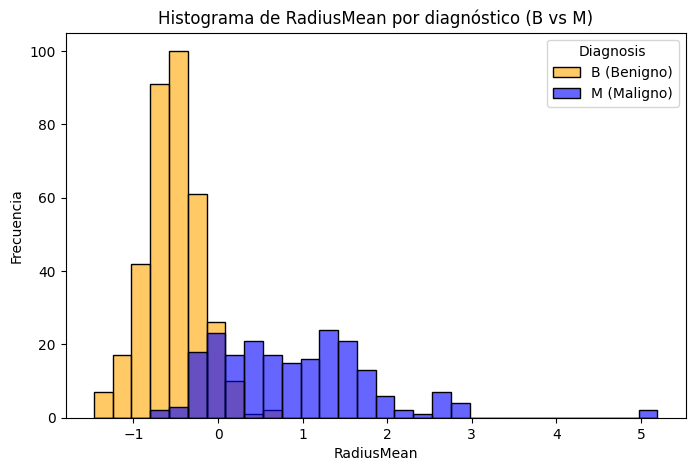

In [13]:
# 10. Histograma de RadiusMean separado por B y M

plt.figure(figsize=(8,5))

sns.histplot(

    data=df_tumor,

    x="RadiusMean",

    hue="Diagnosis",

    bins=30,

    palette={"B": "orange", "M": "blue"},

    alpha=0.6

)

plt.title("Histograma de RadiusMean por diagnóstico (B vs M)")

plt.xlabel("RadiusMean")

plt.ylabel("Frecuencia")

plt.legend(title="Diagnosis", labels=["B (Benigno)", "M (Maligno)"])

plt.show()

11. Generar gráficos de violín para múltiples características.
   Para las columnas:

   - `RadiusMean`
   - `TextureMean`
   - `PerimeterMean`
   - `AreaMean`
   - `SmoothnessMean`
   - `CompactnessMean`
   - `ConcavityMean`
   - `ConcavePointsMean`
   - `Symmetry3`
   - `FractalDimension3`

   Realiza un gráfico múltiple tipo violín, como en el siguiente ejemplo:

```python
data = pd.melt(df.iloc[:, 0:10], id_vars="Diagnosis", var_name="features", value_name="value")
sns.violinplot(x="features", y="value", hue="Diagnosis", data=data, split=True, inner="quart")
plt.xticks(rotation=45)
```

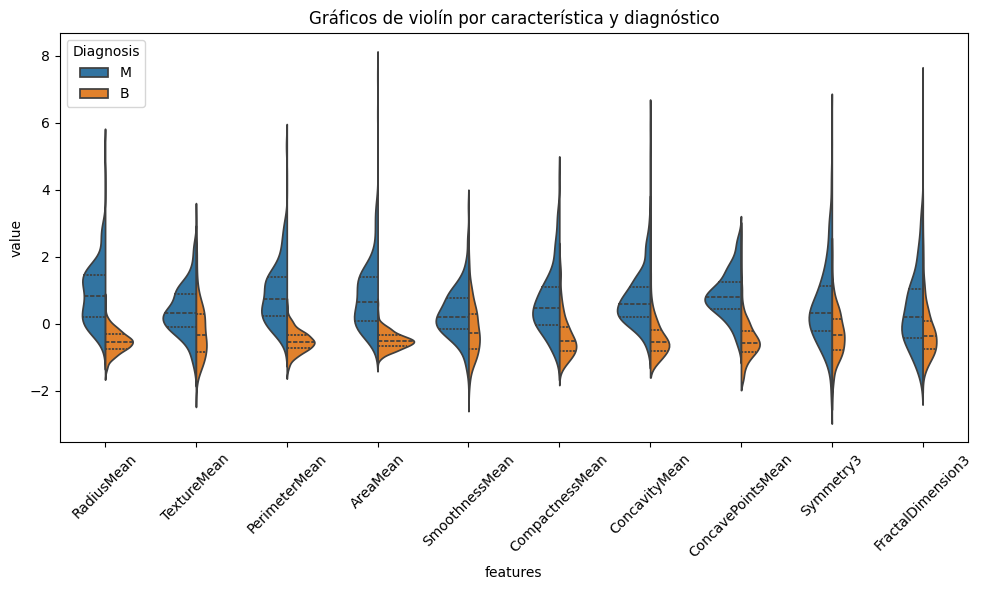

In [14]:
# 11. Gráficos de violín para múltiples características

features_violin = [

    "RadiusMean",

    "TextureMean",

    "PerimeterMean",

    "AreaMean",

    "SmoothnessMean",

    "CompactnessMean",

    "ConcavityMean",

    "ConcavePointsMean",

    "Symmetry3",

    "FractalDimension3",

]



# Construimos un DataFrame en formato "largo" (long format) para seaborn

data_violin = pd.melt(

    df_tumor[features_violin + ["Diagnosis"]],

    id_vars="Diagnosis",

    var_name="features",

    value_name="value",

)



plt.figure(figsize=(10,6))

sns.violinplot(

    x="features",

    y="value",

    hue="Diagnosis",

    data=data_violin,

    split=True,

    inner="quart",

)

plt.xticks(rotation=45)

plt.title("Gráficos de violín por característica y diagnóstico")

plt.tight_layout()

plt.show()

12.  Determinar y eliminar los valores atípicos (`outliers`) en la columna `RadiusMean`.

Para identificarlos, construye un gráfico tipo `boxplot`:

```python
df.boxplot(column="RadiusMean", by='Diagnosis', sym='k.', figsize=(18,6))
```

Usa el rango intercuartílico (IQR) para definir los outliers. Los valores fuera del rango [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR] se consideran outliers. Ejemplo de cómo eliminar estos valores:

```python
Q1 = df['edad'].quantile(0.25)
Q3 = df['edad'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['edad'] < (Q1 - 1.5 * IQR)) | (df['edad'] > (Q3 + 1.5 * IQR)))]
```

Otra alternativa es utilizar el puntaje Z para detectar `outliers`:

```python 
df = df[(np.abs(stats.zscore(df['edad'])) < 3)]
```


<Figure size 1800x600 with 0 Axes>

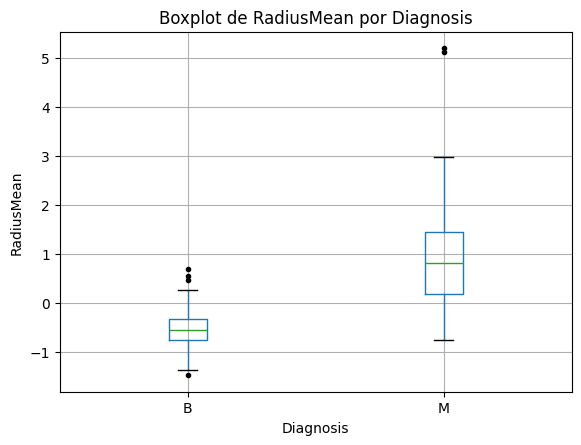

Q1: -0.613313583394348
Q3: 0.3756679928279812
IQR: 0.9889815762223293
Límite inferior: -2.096785947727842
Límite superior: 1.859140357161475

Tamaño original del DataFrame: (569, 43)
Tamaño del DataFrame sin outliers en RadiusMean: (547, 43)


In [15]:
# 12. Determinar y eliminar outliers en RadiusMean usando IQR

# Boxplot de RadiusMean por Diagnosis

plt.figure(figsize=(18, 6))

df_tumor.boxplot(column="RadiusMean", by="Diagnosis", sym="k.")

plt.title("Boxplot de RadiusMean por Diagnosis")

plt.suptitle("")  # quitar título automático de pandas

plt.xlabel("Diagnosis")

plt.ylabel("RadiusMean")

plt.show()



# Cálculo del IQR para RadiusMean

Q1 = df_tumor["RadiusMean"].quantile(0.25)

Q3 = df_tumor["RadiusMean"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR



print("Q1:", Q1)

print("Q3:", Q3)

print("IQR:", IQR)

print("Límite inferior:", lower_bound)

print("Límite superior:", upper_bound)



# Eliminar outliers en RadiusMean según el rango IQR

before_shape = df_tumor.shape

df_tumor = df_tumor[~((df_tumor["RadiusMean"] < lower_bound) | (df_tumor["RadiusMean"] > upper_bound))]

after_shape = df_tumor.shape



print("\nTamaño original del DataFrame:", before_shape)

print("Tamaño del DataFrame sin outliers en RadiusMean:", after_shape)

13. Encontrar la matrix de correlación, emplear el metodo corr(), dentro de seaborn buscar el metodo heatmap() para realizar un grafico de la matrix de correlación.

Matriz de correlación (primeras columnas):
                  Id   Radius1  Texture1  Perimeter1     Area1
Id          1.000000  0.043727  0.082873    0.040186  0.054120
Radius1     0.043727  1.000000  0.305474    0.997308  0.992220
Texture1    0.082873  0.305474  1.000000    0.313113  0.313355
Perimeter1  0.040186  0.997308  0.313113    1.000000  0.990330
Area1       0.054120  0.992220  0.313355    0.990330  1.000000


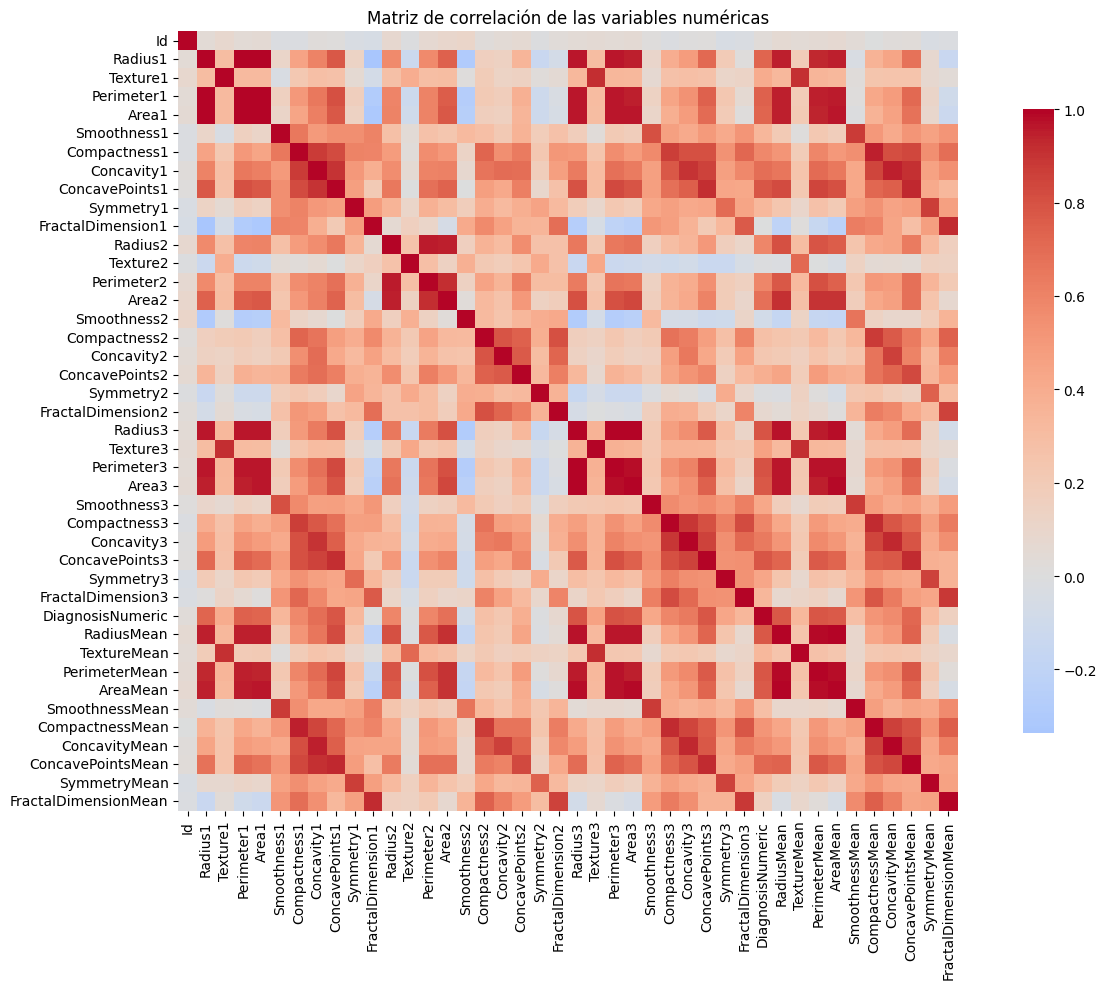

In [16]:
# 13. Matriz de correlación y heatmap

# Calculamos la matriz de correlación sólo para columnas numéricas

corr_matrix = df_tumor.drop(["Diagnosis"], axis=1).corr()



print("Matriz de correlación (primeras columnas):")

print(corr_matrix.iloc[:5, :5])



plt.figure(figsize=(14, 10))

sns.heatmap(

    corr_matrix,

    cmap="coolwarm",

    center=0,

    square=True,

    cbar_kws={"shrink": 0.8},

)

plt.title("Matriz de correlación de las variables numéricas")

plt.tight_layout()

plt.show()

14. ¿Que otro tipo de gráficos pueden ser realizados para entender mejor los datos?

R/ Creo que los gráficos propuestos están muy bien, en especial el plot de violin de las diferentes medias de las característica nos hace ver como se "distribuyen" esa caracteristicas agrupadas por diagnóstico y al estar normalizadas, las podemos comparar con las otras. De este gráfico destaco que me da información acerca de cuales características podrian potencialmente ayudar más a crear la frontera de clasificación: radius_mean y concavity_mean.

Sin embargo, vale la pena explorar gráficos como scatter plots de variables relevantes, o en general, gráficos cruzados que nos digan más acerca de como de correlacionan las variables unas con otras para determinar con buen juicio cuales incluir en el entrenamiento de un modelo por ejemplo, minimizando el sesgo introducido.